# 斯坦福 EE364a 凸优化笔记 - 第二部分：L5-8 对偶理论 

## Lecture 7-8: Duality
核心内容：
- 拉格朗日函数与对偶函数(The Lagrangian & Dual Function)
- 对偶问题 (The Dual Problem)
- 弱对偶与强对偶 (Weak and Strong Duality)
- 最优性条件 (Optimality Conditions)
- 几何解释与灵敏度分析 (Geometric Interpretation & Sensitivity)
- 广义不等式与问题重构 (Generalized Inequalities & Reformulation)

[思维导图](./lecture_5_8_duality_mindmap.md)
[例子](./lecture_5_8_duality_example.md)

## 5.1 核心概念与拉格朗日函数 (The Lagrangian)
### 标准形式问题 (Standard Form Problem)

将原问题 (Primal Problem) 记为：
$$  \begin{aligned}
  & \text{minimize} && f_0(x) \\
  & \text{subject to} && f_i(x) \le 0, \quad i=1,\dots,m \\
  & && h_i(x) = 0, \quad i=1,\dots,p
  \end{aligned}$$
其中 $x \in \mathbb{R}^n$，定义域为 $\mathcal{D}$，最优值为 $p^\star$   

### 拉格朗日函数 (Lagrangian)
为了处理约束，我们通过引入拉格朗日乘子 (Lagrange multipliers) 将约束项加权后“吸收”进目标函数中。定义 $L: \mathbb{R}^n \times \mathbb{R}^m \times \mathbb{R}^p \to \mathbb{R}$ 为：
$$L(x, \lambda, \nu) = f_0(x) + \sum_{i=1}^m \lambda_i f_i(x) + \sum_{i=1}^p \nu_i h_i(x)$$

- $\lambda_i$ 是对应不等式约束 $f_i(x) \le 0$ 的乘子。
- $\nu_i$ 是对应等式约束 $h_i(x) = 0$ 的乘子 。
- ***拉格朗日函数 结果是标量！***

## 5.2 拉格朗日对偶函数 (The Lagrange Dual Function)
### 定义
对偶函数 $g(\lambda, \nu)$ 是拉格朗日函数关于 $x$ 的下确界：
$$g(\lambda, \nu) = \inf_{x \in \mathcal{D}} L(x, \lambda, \nu)$$
$$g(\lambda, \nu) = \inf_{x \in \mathcal{D}} \left( f_0(x) + \sum \lambda_i f_i(x) + \sum \nu_i h_i(x) \right)$$

### 性质
- 凹性 (Concavity): $g(\lambda, \nu)$ 永远是凹函数，无论原问题是否为凸问题。这是因为它是关于 $(\lambda, \nu)$ 的仿射函数族的逐点下确界 。
    - 数学结论
        当我们固定某个特定的 feasible $x$（记为 $\bar{x}$）时，上面的式子变成
        $$L(\bar{x}, \lambda, \nu) = \underbrace{f_0(\bar{x})}_{\text{常数}} + \sum \lambda_i \underbrace{f_i(\bar{x})}_{\text{常数系数}} + \sum \nu_i \underbrace{h_i(\bar{x})}_{\text{常数系数}}$$
        这在 $(\lambda, \nu)$ 的空间里，就是一个仿射函数 (Affine Function)（也就是线性的，形式如 $C + A^T\lambda + B^T\nu$）。 在几何上，这代表一个平面（或超平面）。 仿射函数既是凸函数，也是凹函数。

        对偶函数的定义是：$$g(\lambda, \nu) = \inf_{x \in \mathcal{D}} L(x, \lambda, \nu)$$
        这意味着，对于每一个可能的 $x \in \mathcal{D}$，都存在一个对应的仿射函数（一个平面）。
        - 如果有 1 个 $x$， $g$ 就是一条直线（凹的）。
        - 如果有 2 个 $x$， $g$ 就是这两条直线的较小值（折线，凹的）。
        - 如果有无穷多个 $x$， $g$ 就是这无穷多个平面的下包络面 (Lower Envelope)。
        - 无论原来的 $f_0(x)$ 是什么形状（哪怕是波浪线），只要这里的结构是关于 $\lambda, \nu$ 的线性函数的下确界，结果必然是凹的。
    - 严格证明:
    ---
    定义对偶函数 (dual function)$$g(\lambda,\nu)=\inf_{x\in\mathcal D} L(x,\lambda,\nu).$$
    为方便起见，令 $y=(\lambda,\nu)$。于是$$g(y)=\inf_{x\in\mathcal D} L(x,y).$$
    
    固定任意一个 $x$。由于 $L(x,\lambda,\nu)$ 关于 $(\lambda,\nu)$ 是 仿射的 (affine)，因此它关于 $y$ 也是仿射的。
    
    为了证明 $g$ 是 凹的 (concave)，取任意 $y,y'$ 和任意 $\theta\in[0,1]$。我们有：$$\begin{aligned}
    g(\theta y+(1-\theta)y')
    &=\inf_{x} L\!\left(x,\theta y+(1-\theta)y'\right) \\
    &=\inf_{x}\Big(\theta L(x,y)+(1-\theta)L(x,y')\Big).
    \end{aligned}$$
    
    $\theta$ 能提出来是因为当固定 $x$ 时，$L$ 函数关于变量 $y$（即 $\lambda$ 和 $\nu$）是“线性的” 

    利用一个关键不等式：对于每一个 $x$，$$\theta L(x,y)+(1-\theta)L(x,y')
    \;\ge\;
    \theta\inf_{u} L(u,y) + (1-\theta)\inf_{u} L(u,y'),$$这是因为 $\inf_{u} L(u,y)\le L(x,y)$ 且 $\inf_{u} L(u,y')\le L(x,y')$。因此，对两边取关于 $x$ 的下确界 ($\inf_x$)，该不等式依然成立：$$\begin{aligned}
    g(\theta y+(1-\theta)y')
    &=\inf_{x}\Big(\theta L(x,y)+(1-\theta)L(x,y')\Big) \\
    &\ge \theta\inf_{u} L(u,y) + (1-\theta)\inf_{u} L(u,y') \\
    &= \theta g(y) + (1-\theta)g(y').
    \end{aligned}$$这正是凹性的定义，所以 $g$ 关于 $(\lambda,\nu)$ 是凹函数。

    ---

- 下界性质 (Lower Bound Property): 对于任意 $\lambda \ge 0$ 和任意 $\nu$，对偶函数值总是原问题最优值 $p^\star$ 的下界：$$g(\lambda, \nu) \le p^\star$$
    - 证明思路: 如果 $\tilde{x}$ 是原问题的可行解，且 $\lambda \ge 0$，那么 $\lambda_i f_i(\tilde{x}) \le 0$ (因为 $f_i \le 0$) 且 $\nu_i h_i(\tilde{x}) = 0$。因此 $L(\tilde{x}, \lambda, \nu) \le f_0(\tilde{x})$。取下确界即可得证 


### 示例分析
1. 线性方程的最小范数解 (Least-norm solution)

---
原问题 (Primal Problem):
$$\begin{aligned}
&\text{minimize} && x^T x \\
&\text{subject to} && Ax=b
\end{aligned}$$
这里 $f_0(x)=x^T x$ 是凸二次函数，约束 $Ax=b$ 为线性等式。

**详细推导步骤**
1. 构造拉格朗日函数：引入乘子 $\nu$ (对应等式约束 $Ax-b=0$)
$$L(x,\nu)=x^T x+\nu^T(Ax-b)$$

2. 求下确界 $g(\nu)=\inf_x L(x,\nu)$：对 $x$ 求导并令梯度为 0
$$\nabla_x L(x,\nu)=2x+A^T\nu=0$$
解得
$$x^*=-\tfrac{1}{2}A^T\nu$$

3. 代回得到对偶函数：
$$\begin{aligned}
 g(\nu)
 &=\left(-\tfrac{1}{2}A^T\nu\right)^T\left(-\tfrac{1}{2}A^T\nu\right)+\nu^T\Big(A\left(-\tfrac{1}{2}A^T\nu\right)-b\Big)\\
 &=\tfrac{1}{4}\nu^TAA^T\nu-\tfrac{1}{2}\nu^TAA^T\nu-\nu^T b\\
 &=-\tfrac{1}{4}\nu^TAA^T\nu-b^T\nu
\end{aligned}$$

**结论与直觉**
对偶函数 $g(\nu)$ 是凹二次函数。根据下界性质，对任意 $\nu$，都有
$$-\tfrac{1}{4}\nu^TAA^T\nu-b^T\nu\le p^\star.$$

4. 建立并求解对偶问题

既然我们已经有了对偶函数 $g(\nu) = -\frac{1}{4}\nu^T A A^T \nu - b^T \nu$，对偶问题的目标就是找到一个 $\nu$ 让这个下界最大化（即找到最好的下界）。

对偶问题 (Dual Problem):$$\begin{aligned}
& \text{maximize} && g(\nu) = -\frac{1}{4}\nu^T A A^T \nu - b^T \nu
\end{aligned}$$

*注意：因为原约束是等式约束 $Ax=b$，所以对偶变量 $\nu$ 没有非负性约束 ($\nu \succeq 0$)，它是一个无约束的优化问题。*

求解 $\nu^\star$:这是一个关于 $\nu$ 的无约束凹二次函数最大化问题。为了求最大值，我们可以直接求梯度并令其为 0：

由此得到线性方程：$$\frac{1}{2} A A^T \nu = -b$$
$$A A^T \nu = -2b$$ 
假设行向量组 $A$ 是满秩的（即 $A A^T$ 是可逆的），我们可以解出最优的对偶变量：$$\nu^\star = -2 (A A^T)^{-1} b$$

5. 恢复原问题最优解 $x^\star$
现在我们已经求出了最优乘子 $\nu^\star$，可以利用之前推导出的关系式 $x = -(1/2) A^T \nu$ 来求出 $x^\star$。 将 $\nu^\star$ 代入：
$$\begin{aligned}
x^\star &= -\frac{1}{2} A^T \nu^\star \\
&= -\frac{1}{2} A^T \left( -2 (A A^T)^{-1} b \right) \\
&= A^T (A A^T)^{-1} b
\end{aligned}$$

6. 结论
得到了原问题（最小范数解）的显式解析解：$$x^\star = A^T (A A^T)^{-1} b$$

**这正是熟知的线性方程组最小范数解的公式**。 其中 $A^\dagger = A^T (A A^T)^{-1}$ 被称为 $A$ 的右伪逆 (Right Pseudo-inverse)。总结一下流程：
- 写出拉格朗日函数 $L$。
- 求 $L$ 关于 $x$ 的极小值，得到 $x$ 关于 $\nu$ 的表达式 $x(\nu)$ 和对偶函数 $g(\nu)$。
- 最大化 $g(\nu)$ 求出最优乘子 $\nu^\star$。
- 将 $\nu^\star$ 代回 $x(\nu)$ 得到最终解 $x^\star$。

---

- 标准形式线性规划 (Standard Form LP)

---
原问题 (Primal Problem):
$$\begin{aligned}
&\text{minimize} && c^T x \\
&\text{subject to} && Ax=b,\ x\ge 0
\end{aligned}$$

**详细推导步骤**
1. 构造拉格朗日函数：引入乘子 $\nu$ (对应 $Ax=b$) 和 $\lambda\ge 0$ (对应 $-x\le 0$)
$$L(x,\lambda,\nu)=c^T x+\nu^T(Ax-b)-\lambda^T x$$
$$\quad\quad\quad\quad\ \ =-b^T\nu+(c+A^T\nu-\lambda)^T x$$

注意：这里将含有 $x$ 的项合并了。

2. 求下确界 $g(\lambda,\nu)=\inf_x L(x,\lambda,\nu)$：由于 $L$ 关于 $x$ 是线性函数，只有两种情况：
- 如果斜率（即 $x$ 的系数）不为 0，则下确界为 $-\infty$。
- 如果斜率为 0，则函数值为常数项。

因此
$$g(\lambda,\nu)=\inf_x L=\begin{cases}
-b^T\nu, & c+A^T\nu-\lambda=0 \\
-\infty, & \text{其他情况}
\end{cases}$$

**结论与直觉**

这就是标准形式 LP 对偶形式的来源。对偶问题通常写为：
$$\begin{aligned}
&\text{maximize} && -b^T\nu \\
&\text{subject to} && A^T\nu+c=\lambda,\ \lambda\ge 0\ \ (\text{即 } A^T\nu+c\ge 0)
\end{aligned}$$

---

3. 等式约束范数最小化 (Equality constrained norm minimization)
---
这是一个比“最小二乘”更通用的问题，目标函数是任意范数 $\lVert x\rVert$（如 $\ell_1$ 范数，常用于稀疏解）。

**原问题**
$$\begin{aligned}
&\text{minimize} && \lVert x\rVert \\
&\text{subject to} && Ax=b
\end{aligned}$$

**详细推导步骤**
1. 构造拉格朗日函数：
$$L(x,\nu)=\lVert x\rVert+\nu^T(Ax-b)=\lVert x\rVert-( -A^T\nu)^T x-b^T\nu$$

2. 利用对偶范数 (Dual Norm) 的定义：
回顾对偶范数的定义：$\lVert u\rVert_* = \sup_{\lVert x\rVert\le 1} u^T x$，可推出重要性质
$$\inf_x (\lVert x\rVert-u^T x)=\begin{cases}
0, & \lVert u\rVert_*\le 1 \\
-\infty, & \text{其他情况}
\end{cases}$$
（原因：如果 $\lVert u\rVert_*>1$，总能找到一个 $x$ 方向让 $u^T x$ 比 $\lVert x\rVert$ 增长得更快，从而差值趋向负无穷。）

3. 应用到本题：令 $u=-A^T\nu$。（我觉得能想到这一步确实是技巧）
$$g(\nu)=-b^T\nu+\inf_x (\lVert x\rVert-( -A^T\nu)^T x)$$
因此
- 如果 $\lVert -A^T \nu\rVert_* \le 1$：*$\inf_x (\dots)$ 部分等于 0。所以 $g(\nu) = -b^T \nu + 0 = -b^T \nu$。
- 如果 $\lVert -A^T \nu\rVert_* > 1$：*$\inf_x (\dots)$ 部分等于 $-\infty$。所以 $g(\nu) = -b^T \nu - \infty = -\infty$。

$$g(\nu)=\begin{cases}
-b^T\nu, & \lVert A^T\nu\rVert_*\le 1 \\
-\infty, & \text{其他情况}
\end{cases}$$

**结论**

因为对偶问题的目标是 Maximize $g(\nu)$，而取值为 $-\infty$ 的点显然不可能是最大值点（除非无解），所以我们只需要关注那些让 $g(\nu)$ 有意义（有限值）的区域。

对偶问题变成
$$\begin{aligned}
&\text{maximize} && -b^T\nu \\
&\text{subject to} && \lVert A^T\nu\rVert_*\le 1
\end{aligned}$$

这把可能非光滑目标（如 $\ell_1$ 范数）的问题转化为带范数约束的凸问题。

---

4. 双向划分 (Two-way partitioning) —— 非凸问题的经典例子

---
这是一个组合优化问题（把 $n$ 个物品分成两组，使得总代价最小），原本非常难解 (NP-hard)。

**原问题 (非凸)**
$$\begin{aligned}
&\text{minimize} && x^T W x \\
&\text{subject to} && x_i^2=1,\quad i=1,\dots,n
\end{aligned}$$
约束 $x_i\in\{-1,1\}$ 是离散的，且 $x^T W x$ 未必是凸函数（$W$ 未必半正定）。

*为什么把问题frame成二次型而不是线性问题？*

这源于问题的物理定义：双向划分 (Two-way Partitioning)。

**场景假设**：我们要把 $n$ 个人分成两组（比如 A 组和 B 组）。
- 令 $x_i=+1$ 代表第 $i$ 个人去 A 组。
- 令 $x_i=-1$ 代表第 $i$ 个人去 B 组。
- 这就是约束 $x_i^2=1$ 的由来（$x$ 只能取 $+1$ 或 $-1$）。

**成本的来源**：在这个问题中，成本不是由单个人产生的，而是由两个人之间的关系产生的（比如“张三和李四如果分在同一组会吵架，产生 10 点的消耗；如果分在不同组，产生 -10 点的消耗”）。

我们需要一个数学表达式来捕捉这种“同组 vs 不同组”的逻辑：
- 情况一：同组，如果 $i$ 和 $j$ 都在 A 组 $(1,1)$ 或都在 B 组 $(-1,-1)$，则
$$x_i x_j=1$$
- 情况二：不同组，如果一个在 A、一个在 B $(1,-1)$ 或 $(-1,1)$，则
$$x_i x_j=-1$$

**构造总花费**：设 $W_{ij}$ 代表 $i$ 和 $j$ 这两个人的“互动权重”。我们希望计算所有配对的总权重：
$$\text{总花费}=\sum_{i=1}^n\sum_{j=1}^n x_i W_{ij} x_j$$
- 如果 $i,j$ 同组，这一项贡献 $1\cdot W_{ij}=W_{ij}$。
- 如果 $i,j$ 不同组，这一项贡献 $-1\cdot W_{ij}=-W_{ij}$。

上面的双重求和公式，写成矩阵形式就是：
$$\sum_i\sum_j x_i W_{ij} x_j = x^T W x$$


**详细推导步骤**
1. 构造拉格朗日函数：引入乘子 $\nu$ 处理等式约束 $x_i^2-1=0$：
$$\begin{aligned}
L(x,\nu)
&=x^T W x+\sum_{i=1}^n \nu_i(x_i^2-1) \\
&=x^T W x+x^T\mathrm{diag}(\nu)x-\mathbf{1}^T\nu \\
&=x^T\big(W+\mathrm{diag}(\nu)\big)x-\mathbf{1}^T\nu
\end{aligned}$$

2. 求下确界：这是一个关于 $x$ 的二次型。要使下确界有限（不是 $-\infty$），中间的矩阵必须半正定；若半正定，则最小值为 0（取 $x=0$）。

因此
$$g(\nu)=\begin{cases}
-\mathbf{1}^T\nu, & W+\mathrm{diag}(\nu)\succeq 0 \\
-\infty, & \text{其他情况}
\end{cases}$$

**结论与直觉**
对偶问题为：
$$\begin{aligned}
&\text{maximize} && -\mathbf{1}^T\nu \\
&\text{subject to} && W+\mathrm{diag}(\nu)\succeq 0
\end{aligned}$$
这是一个半定规划 (SDP)，可高效求解。对偶最优值 $d^\star$ 给出原问题最优值 $p^\star$ 的下界，常用于分支定界等算法中。

---

5. 拉格朗日对偶与共轭函数 (Lagrange dual and conjugate function)

Boyd展示了如何利用共轭函数 (Conjugate Function) $f^*(y)=\sup_x (y^T x-f(x))$ 快速推导对偶函数，这是一个通用“公式”。

---
**原问题模型**
$$\begin{aligned}
&\text{minimize} && f_0(x) \\
&\text{subject to} && Ax\le b,\quad Cx=d
\end{aligned}$$

**利用共轭函数的推导**
1. 写出拉格朗日函数：
$$\begin{aligned}
L(x,\lambda,\nu)
&=f_0(x)+\lambda^T(Ax-b)+\nu^T(Cx-d) \\
&=f_0(x)+(A^T\lambda+C^T\nu)^T x-b^T\lambda-d^T\nu
\end{aligned}$$

2. 求下确界：我们需要计算 $\inf_x\,(f_0(x)+y^T x)$，其中 $y=A^T\lambda+C^T\nu$。
回顾共轭函数定义：
$$f^*(y)=\sup_x (y^T x-f(x))=-\inf_x (f(x)-y^T x)$$
注意符号变化，可得
$$\inf_x (f_0(x)+y^T x)=-f_0^*(-y).$$

3. 得到对偶函数：
$$g(\lambda,\nu)=-b^T\lambda-d^T\nu-f_0^*(-A^T\lambda-C^T\nu).$$

**应用示例：最大熵问题 (Entropy maximization)**
原问题：$\min \sum_i x_i\log x_i\ \text{s.t.}\ Ax\le b,\ \mathbf{1}^T x=1$。

已知 $f_0(x)=\sum_i x_i\log x_i$ 的共轭函数为
$$f_0^*(y)=\sum_i e^{y_i-1}.$$

因此可以直接套用上面的公式，无需每次重新推导，大大简化过程。

========================================================================================================

求$g(u) = u \log u$ （定义域 $u > 0$）的共轭函数。
$$g^*(v) = \sup_{u > 0} \left( v \cdot u - g(u) \right) = \sup_{u > 0} \left( vu - u \log u \right)$$

这实际上就是求函数 $h(u) = vu - u \log u$ 的最大值。

**1.求导（把 $v$ 看作常数）**
$$h'(u)=v-(1\cdot \log u+u\cdot \tfrac{1}{u})=v-(\log u+1)$$

**2. 令导数为 0（寻找极值点）**
$$v-\log u-1=0 \quad\Rightarrow\quad \log u=v-1$$
解得最优的 $u^*$：
$$u^*=e^{v-1}$$
（注：$h''(u)=-1/u$，在 $u>0$ 时恒为负，说明这是最大值点。）

**3.代回求最大值**
$$\begin{aligned}
 g^*(v)
 &=vu^*-u^*\log u^* \\
 &=v(e^{v-1})-(e^{v-1})\log(e^{v-1}) \\
 &=ve^{v-1}-e^{v-1}(v-1) \\
 &=e^{v-1}
\end{aligned}$$

所以，一元函数 $u\log u$ 的共轭函数是 $e^{v-1}$。


---

共轭函数这一块基本没看懂

## 5.3 对偶问题 (The Dual Problem)
既然 $g(\lambda, \nu)$ 提供了 $p^\star$ 的下界，我们自然希望找到最好的下界（即最大的下界）。

拉格朗日对偶问题:$$  \begin{aligned}
  & \text{maximize} && g(\lambda, \nu) \\
  & \text{subject to} && \lambda \succeq 0
  \end{aligned}$$
  
性质: 这是一个凸优化问题（因为目标函数 $g$ 是凹的，约束是线性的），无论原问题是否是凸的。其最优值记为 $d^\star$ 。



## 5.4 弱对偶与强对偶 (Weak and Strong Duality)

### 弱对偶/强对偶
**弱对偶 (Weak Duality)**
$$d^\star \le p^\star$$
- 含义： 对偶问题的最优值 $d^\star$ 永远不会超过原问题的最优值 $p^\star$ 。
- 适用性： 这个性质永远成立，无论原问题是凸的还是非凸的 。
- 用途： 它可以用来寻找困难问题的下界。例如，双向划分问题是一个难解的非凸问题，但通过求解其对偶问题（SDP），我们可以得到一个non-trivial的下界 

**强对偶 (Strong Duality)**
$$d^\star = p^\star$$
- 含义： 对偶间隙为 0，求解对偶问题等同于求解原问题。
- 适用性： 并不总是成立。但在凸优化问题中，通常是成立的 。
- 条件： 需要满足约束资格 (Constraint Qualifications)

### Slater 条件 (Slater's Constraint Qualification)
这是保证强对偶成立的最常用充分条件。

- 定义：如果原问题是凸问题，且是严格可行 (Strictly Feasible) 的，即存在一个点 $x \in \text{int}\mathcal{D}$ 使得：$$f_i(x) < 0, \quad i=1,\dots,m, \quad Ax=b$$那么强对偶成立 。
- More
    - 结果： Slater 条件不仅保证了 $d^\star = p^\star$，还保证了对偶最优解是可以取到的（dual optimum is attained）。
    - 仿射函数的特例： 如果某些不等式约束 $f_i(x)$ 是仿射函数（线性的），那么这些约束不需要严格小于 0，只需要小于等于 0 即可 。也就是说，Slater 条件对线性约束是宽松的。

**为什么 Slater 条件能保证“对偶最优解可以取到”？**
这句话的意思是：不仅强对偶成立（$d^\star = p^\star$），而且一定能找到一组具体的 $(\lambda^\star, \nu^\star)$ 使得 $g(\lambda^\star, \nu^\star) = p^\star$。

**直觉解释(Gemini)**
想象你在买东西（原问题求最小花费）：
- 弱对偶告诉我们：哪怕你再怎么跟老板砍价（寻找下界），价格也不会低于成本价。
- 强对偶告诉我们：最终成交价 $p^\star$ 恰好等于成本价 $d^\star$。
- “对偶最优解可以取到”告诉我们：存在一个确定的成本清单。

**为什么 Slater 条件能保证这一点？**
Slater 条件本质上保证了原问题**不过分敏感**。从几何/灵敏度的角度看：
- 最优对偶变量 $\lambda^\star$ 实际上是影子价格，代表当我们稍微放松约束 $f_i(x) \le 0$ 时，最优值 $p^\star$ 下降的速率（斜率）。
- 如果原问题没有严格可行点（所有可行点都挤在边界 $f_i(x)=0$ 上），约束可能极其脆弱，稍微一动可行域就消失，最优值可能瞬间跳变。
- 这时，最优值对约束的变化率可能是无穷大。
- 斜率如果是无穷大，就意味着需要无穷大的 $\lambda^\star$，从而不存在一个有限的对偶最优解。

**Slater 的作用**
它要求“存在一个严格满足约束的点”，保证可行域有一个“宽敞的内部”。这使得最优值 $p^\star$ 随约束变化是平缓的、斜率有限的，因此一定存在一个有限的 $\lambda^\star$ 作为对偶最优解。


### 几何解释
在 $(u, t)$ 空间中定义集合 $G = \{(f_1(x), f_0(x)) \mid x \in \mathcal{D}\}$。对偶函数 $g(\lambda)$ 对应于该集合的支撑超平面。强对偶性意味着在最优值点 $(0, p^\star)$ 处存在非垂直的支撑超平面。

Boyd在P131给了一个图，有点抽象。细看后应该这样理解

$$g(\lambda) = \inf_x L(x, \lambda) = \inf_x \left( f_0(x) + \lambda f_1(x) \right)$$
就是：固定住 $\lambda$，让 $x$ 随便变，看看$f_0(x) + \lambda f_1(x)$最小能有多小

线约束函数值 $f_1(x)$ 记作 横坐标 $u$。把 目标函数值 $f_0(x)$ 记作 纵坐标 $t$。把所有 $x$ 能产生的后果 $(f_1(x), f_0(x))$ 都在图上点出来，这些点的集合就是那个灰色的腰果形状 $\mathcal{G}$。然后，把公式里的 $f_0$ 和 $f_1$ 替换掉：
- $f_0(x) \to t$
- $f_1(x) \to u$
- “遍历所有 $x$” $\to$ “遍历灰色区域 $\mathcal{G}$ 里所有的点 $(u,t)$”

==> 上面$g(\lambda)$就变成了：$$g(\lambda) = \inf_{(u,t) \in \mathcal{G}} (t + \lambda u)$$

设这个最小值为 $C$（也就是我们想求的 $g(\lambda)$）。
$$t + \lambda u = C$$
改成 ($y = kx + b$)形式：
$$t = -\lambda u + C$$
- $t$ 和 $u$：坐标轴上的变量。
- $-\lambda$：直线的斜率。因为规定 $\lambda \ge 0$，所以 $-\lambda \le 0$，这意味着这根直线是向右下倾斜（或者水平）的。
- $C$：直线在纵轴上的截距。

结论：计算 $g(\lambda)$ 的过程，就是在保持斜率 $-\lambda$ 不变的情况下，把这根直线从 $-\infty$（最底下）往上推，直到它刚刚碰到灰色区域 $\mathcal{G}$ 的底部。这时候，这根线就叫支撑超平面，而在纵轴上的读数 $C$，就是 $g(\lambda)$。
![dual_function](./image/dual_function.png) 


对偶函数 g(λ) 是由无数个关于 λ的“线性函数”取最小值得到的。 可以想像成：求解对偶函数 g(λ)就是在用一把直尺去测量这个复杂图形的底部轮廓。由于直尺是直的，如果图形有凹陷，直尺测出来的高度的 $d^*$ 永远会低于真实的谷底高度 $p^*$


### 应用举例
#### 不等式形式线性规划 (Inequality form LP)

- **原问题**: $$\min c^T x \ \text{subject to } Ax \le b.$$

- **对偶函数**:
$$g(\lambda)=\inf_x \big(c^T x+\lambda^T(Ax-b)\big)=-b^T\lambda+\inf_x (A^T\lambda+c)^T x$$
如果 $A^T\lambda+c\ne 0$，下确界为 $-\infty$（求下确界时，$x$ 是没有任何约束的，因为所有的约束都已经通过 $\lambda$ 放到拉格朗日函数里去了，$x$ 可以取 $\mathbb{R}^n$ 里的任何值， 这个负无穷的下确界没有意义）。因此必须满足 $A^T\lambda+c=0$。

- **对偶问题**:
$$\begin{aligned}
&\text{maximize} && -b^T\lambda \\
&\text{subject to} && A^T\lambda+c=0,\ \lambda\succeq 0
\end{aligned}$$

- **强对偶性**: 根据 Slater 条件，只要原问题可行（存在 $x$ 满足 $Ax\le b$），强对偶就成立。事实上，对于 LP，除非原问题和对偶问题都不可行，否则强对偶总是成立。

#### 二次规划 (Quadratic Program, QP)

- **原问题**: $$\min x^T P x \ \text{subject to } Ax \le b \ \text{(假设 } P \succ 0).$$

- **对偶函数**: $L(x,\lambda)=x^T P x+\lambda^T(Ax-b)$。
对 $x$ 求导并令其为 0：$2Px+A^T\lambda=0 \Rightarrow x=-(1/2)P^{-1}A^T\lambda$。
代回得到
$$g(\lambda)=-\tfrac{1}{4}\lambda^T A P^{-1} A^T\lambda-b^T\lambda.$$

- **对偶问题**:
$$\begin{aligned}
\text{maximize}\quad & -\tfrac{1}{4}\lambda^T A P^{-1} A^T\lambda-b^T\lambda \\
\text{subject to}\quad & \lambda\succeq 0
\end{aligned}$$

- **强对偶性**: 总是成立。

#### 强对偶性的非凸问题 (A nonconvex problem with strong duality)

说明强对偶不仅仅属于凸问题。

- **原问题**:
$$\begin{aligned}
\text{minimize}\quad & x^T A x + 2b^T x \\
\text{subject to}\quad & x^T x \le 1
\end{aligned}$$
其中 $A$ 不一定半正定，因此目标函数非凸；该问题也称为信赖域子问题 (Trust Region Subproblem)。

- **对偶推导**: $L(x,\lambda)=x^T(A+\lambda I)x+2b^T x-\lambda$。

拉格朗日函数原始形式：$$L(x, \lambda) = f_0(x) + \lambda f_1(x) = (x^T A x + 2b^T x) + \lambda (x^T x - 1)$$
$$L(x, \lambda) = x^T A x + 2b^T x + \lambda x^T I x - \lambda$$
$$L(x, \lambda) = x^T \underbrace{(A + \lambda I)}_{\text{新的大矩阵}} x + 2b^T x - \lambda$$

对偶函数 $g(\lambda)$：$$g(\lambda) = \inf_x L(x, \lambda)$$这意味着：把 $\lambda$ 当作常数，我们要找到一个 $x$，让上面那个二次函数的值最小。

这个是否有最小值这取决于二次项系数矩阵 $P$（也就是 $A + \lambda I$）的性质。所必须强制要求：$$A + \lambda I \succeq 0$$(这保证了抛物面是开口向上的，或者至少是平底的碗，这样才有谷底)。

求下确界方法：求导：$$\nabla_x L(x, \lambda) = 2(A + \lambda I)x + 2b$$
令其为 0：$$2(A + \lambda I)x + 2b = 0$$
$$(A + \lambda I)x = -b$$

==> 为使下确界有界，要求 $A+\lambda I\succeq 0$，且最优解满足 $(A+\lambda I)x=-b$。

==> 最优的 $x$ 必须满足：$$x = -(A+\lambda I)^{-1}b$$

把这个 $x$ 代回到拉格朗日函数里($A$对称，$(A+\lambda I)$ 对称)
$$\begin{aligned}
g(\lambda) &= L(x, \lambda) \\
&= x^T(A+\lambda I)x + 2b^T x - \lambda \\
&= \left[ -(A+\lambda I)^{-1}b \right]^T (A+\lambda I) \left[ -(A+\lambda I)^{-1}b \right] + 2b^T \left[ -(A+\lambda I)^{-1}b \right] - \lambda \\
&= -b^T (A+\lambda I)^{-1} b - \lambda
\end{aligned}$$
==> 原始对偶问题是：$$\text{Maximize} \quad -b^T (A+\lambda I)^{-1} b - \lambda$$

目标函数里有矩阵的逆 $(A+\lambda I)^{-1}$，我们要把它线性化。引入辅助变量$$t \ge b^T (A+\lambda I)^{-1} b$$
目标函数就变成
$$\begin{aligned}
\text{maximize}\quad & -t-\lambda \\
\text{subject to}\quad & t \ge b^T (A+\lambda I)^{-1} b \\
& A+\lambda I \succeq 0
\end{aligned}$$

然后用舒尔补引理（这个想不到了 只能靠Gemini解）
定理内容：

对于形如 $\begin{bmatrix} X & B \\ B^T & C \end{bmatrix}$ 的对称分块矩阵（其中 $X \succ 0$），
它半正定（$\succeq 0$） 当且仅当 $C - B^T X^{-1} B \succeq 0$。

套用到我们这里：我们要处理的不等式是：$$t - b^T (A+\lambda I)^{-1} b \ge 0$$
- 对应定理里的 $C$ 就是标量 $t$。
- 对应定理里的 $B$ 就是向量 $b$。
- 对应定理里的 $X$ 就是矩阵 $A+\lambda I$。

根据舒尔补引理，上面这个标量不等式直接等价于下面这个线性矩阵不等式 (LMI)：
$$\begin{bmatrix}
A+\lambda I & b \\
b^T & t
\end{bmatrix} \succeq 0$$


- **对偶问题**: 最终可以写成半定规划 (SDP) 形式：
$$\begin{aligned}
\text{maximize}\quad & -t-\lambda \\
\text{subject to}\quad & \begin{bmatrix}A+\lambda I & b\\ b^T & t\end{bmatrix} \succeq 0
\end{aligned}$$

- **结论**: 尽管原问题非凸，但在这个特定问题中，强对偶依然成立。


## 5.5 最优性条件 (Optimality Conditions)
一旦强对偶性成立，我们能得到什么好用的结论？ 答案： 互补松弛性 和 KKT 条件。

**互补松弛性 (Complementary Slackness)**
强对偶成立意味着 $p^\star = d^\star$，可以写出下面的不等式链：
$$
\begin{aligned}
& f_0(x^\star) = g(\lambda^\star,\nu^\star)
= \inf_x \Big( f_0(x) + \sum_{i=1}^m \lambda_i^\star f_i(x) + \sum_{i=1}^p \nu_i^\star h_i(x) \Big) \\
&\le f_0(x^\star) + \sum_{i=1}^m \lambda_i^\star f_i(x^\star) + \sum_{i=1}^p \nu_i^\star h_i(x^\star) \\
&\le f_0(x^\star)
\end{aligned}
$$
因此两个不等式都取等号，得到：
- $x^\star$ 最小化 $L(x,\lambda^\star,\nu^\star)$；
- $\lambda_i^\star f_i(x^\star)=0,\ i=1,\dots,m$。


这表明：如果第 $i$ 个约束未起作用（即 $f_i(x^\star) < 0$），则对应的乘子 $\lambda_i^\star$ 必须为 0；如果乘子 $\lambda_i^\star > 0$，则该约束必须紧绷（即 $f_i(x^\star) = 0$）。

附：
- 紧绷 (Tight) = 起作用 (Active) = 卡在边界上 ($=$) = 限制。
- 松弛 (Slack) = 不起作用 (Inactive) = 在内部 ($<$) = 没限制。


---
详细推导：
假设强对偶性成立，即 $p^* = d^*$。
- $p^* = f_0(x^*)$ （这是定义）。
- $d^* = g(\lambda^*, \nu^*) = \inf_x L(x, \lambda^*, \nu^*)$ （这是对偶函数的定义）
- $\inf_x L(x, \dots) \le L(x^*, \lambda^*, \nu^*)$ （最小值肯定小于等于在 $x^*$ 处的函数值）。
- 展开 $L$：$L(x^*, \dots) = f_0(x^*) + \sum \lambda_i^* f_i(x^*) + \sum \nu_i^* h_i(x^*)$。
- 因为 $x^*$ 可行，所以 $h_i(x^*)=0$，且 $f_i(x^*) \le 0$。又因为 $\lambda^* \ge 0$，所以中间那一项 $\sum \lambda_i^* f_i(x^*) \le 0$。
- 因此：$L(x^*, \dots) \le f_0(x^*)$。

如果强对偶成立（头尾相等，即 $d^* = p^*$），那么上面所有的“小于等于”都必须变成“严格等于”。这意味着中间那项必须为 0：$$\sum_{i=1}^m \lambda_i^\star f_i(x^\star) = 0$$
因为每一项都是 $\lambda_i^* \ge 0$ 且 $f_i(x^*) \le 0$，它们的乘积是非正的。要让一堆非正数的和等于 0，每一项都必须必须是 0。

---


**KKT 条件 (Karush-Kuhn-Tucker Conditions)**
对于目标函数和约束函数可微的问题，任何一对原问题和对偶问题的最优解必须满足以下四组条件：
- 原问题可行性 (Primal Constraints): $f_i(x) \le 0,\ h_i(x) = 0$。 这一步保证算出来的 $x$ 是合法的解。
- 对偶可行性 (Dual Constraints): $\lambda \succeq 0$。这一步保证惩罚（乘子）是非负的，这是对偶理论的基本设定。
- 互补松弛性 (Complementary Slackness): $\lambda_i f_i(x) = 0$。
- 拉格朗日梯度为零 (Gradient of Lagrangian vanishes):（梯度是对$x$）
$$\nabla_x L(x^*, \lambda^*, \nu^*) = \nabla f_0(x^*) + \sum \lambda_i^* \nabla f_i(x^*) + \sum \nu_i^* \nabla h_i(x^*) = 0$$



对拉格朗日梯度为0解释

定义：对偶函数 $g(\lambda^*)$ 的定义就是“固定 $\lambda^*$，寻找拉格朗日函数 $L(x, \lambda^*)$ 关于 $x$ 的最小值”。$$g(\lambda^*) = \min_x L(x, \lambda^*)$$

既然是求“最小值”，这就变成了一个无约束的求导问题。想象 $L(x, \lambda^*)$  一个光滑函数的最底部（极小值点），切线一定是水平的，也就是梯度（导数）等于 0。$$\nabla_x L = 0$$

同时也引出$$\nabla f_0(x^*) + \lambda^* \nabla f_1(x^*) = 0$$。 目标梯度和约束梯度一定是”相反“的


**重要结论**
对于任何强对偶成立的优化问题，KKT 条件是局部最优解的必要条件。对于凸优化问题，KKT 条件是全局最优解的充要条件（只要满足 Slater 条件）。这使得我们可以通过求解 KKT 方程组来直接寻找最优解（例如注水算法 Water-filling）。



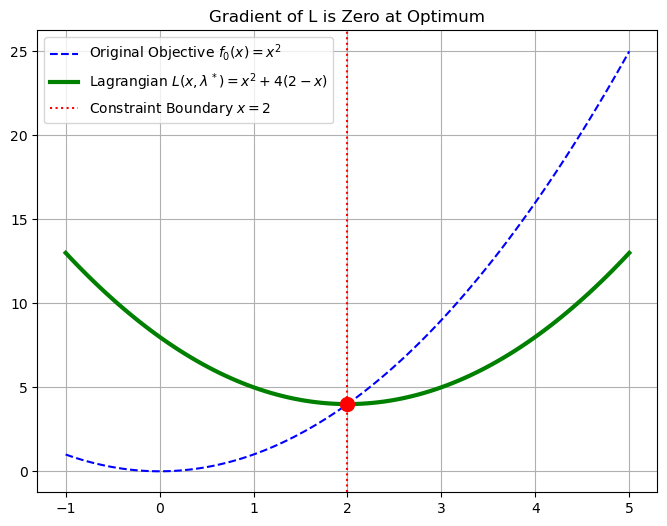

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the primal problem
# Objective: minimize x^2 (minimum at 0)
# Constraint: x >= 2 (i.e., 2 - x <= 0)
x = np.linspace(-1, 5, 100)
f0 = x**2            # objective function
f1 = 2 - x           # constraint function (<= 0)

# 2. Optimal solution
# Clearly x* = 2.
# From KKT, solve for lambda*:
# Derivative 2x - lambda = 0 -> 4 - lambda = 0 -> lambda = 4
lambda_star = 4

# 3. Construct the Lagrangian
L = f0 + lambda_star * f1  # L = x^2 + 4(2-x)

# 4. Plot
plt.figure(figsize=(8, 6))
plt.plot(x, f0, 'b--', label='Original Objective $f_0(x) = x^2$')
plt.plot(x, L, 'g-', linewidth=3, label='Lagrangian $L(x, \lambda^*) = x^2 + 4(2-x)$')

# Mark the optimum
plt.axvline(x=2, color='r', linestyle=':', label='Constraint Boundary $x=2$')
plt.scatter([2], [4], color='red', s=100, zorder=5)

# Title and axes
plt.title("Gradient of L is Zero at Optimum")
plt.legend()
plt.grid(True)
plt.show()

## 5.6 扰动与灵敏度分析 (Perturbation and Sensitivity Analysis)

对偶变量 $(\lambda^\star, \nu^\star)$ 有着重要的经济学或物理学解释：它们代表了最优值 $p^\star$ 对约束条件变化的灵敏度。

### 扰动问题
- 原问题：$$\begin{aligned} \text{min } & f_0(x) \\ \text{s.t. } & f_i(x) \le 0 \\ & h_i(x) = 0 \end{aligned}$$最优值记为 $p^\star(0, 0)$（表示约束右边是 0）。
- 扰动问题： 将约束条件的右边（Right-Hand Side, RHS）从 0 改成变量 $u_i$ 和 $v_i$。$$\begin{aligned} \text{min } & f_0(x) \\ \text{s.t. } & f_i(x) \le u_i \\ & h_i(x) = v_i \end{aligned}$$
最优值记为 $p^\star(u, v)$。这是一个关于扰动量 $u$ 和 $v$ 的函数。

直觉理解：
- 如果 $u_i > 0$：表示放松了约束（原来要求 $\le 0$，现在只要 $\le 0.1$ 就行）。既然限制少了，我们通常能找到更好的解，所以成本 $p^\star$ 会下降。
- 如果 $u_i < 0$：表示收紧了约束（要求 $\le -0.1$）。限制更严了，成本 $p^\star$ 通常会上升。


### 全局灵敏度
$$p^\star(u, v) \ge p^\star(0,0) - \lambda^{\star T} u - \nu^{\star T} v.$$

推导：

- 设 $x$ 是扰动问题（参数为 $u, v$）的任意可行解。根据强对偶性， $p^\star(0,0) = g(\lambda^\star, \nu^\star)$。所以写成 $p^\star(0,0)$，是因为在灵敏度分里，我们把最优值看作是一个关于扰动量 $(u, v)$ 的函数。
- 根据对偶函数的定义：$$\begin{aligned} p^\star(0,0) &= \inf_z \left( f_0(z) + \sum \lambda_i^\star f_i(z) + \sum \nu_i^\star h_i(z) \right) \\ &\le f_0(x) + \sum \lambda_i^\star f_i(x) + \sum \nu_i^\star h_i(x) \end{aligned}$$
- 因为 $x$ 满足扰动后的约束（即 $f_i(x) \le u_i$ 和 $h_i(x) = v_i$），且 $\lambda^\star \ge 0$：
$$\text{上式 } \le f_0(x) + \sum \lambda_i^\star u_i + \sum \nu_i^\star v_i$$
$$p^\star(0,0) \le f_0(x) + \lambda^{\star T} u + \nu^{\star T} v$$
移项即得结论

### 局部灵敏度和影子价格

如果 $p^\star(u, v)$ 可微，则：

推导思路：
- 上面已经得到全局灵敏度不等式
$$p^\star(u, v) \ge p^\star(0,0) - \lambda^{\star T} u - \nu^{\star T} v.$$
- 这正是凸函数的“次梯度不等式”形式：
$$p^\star(u, v) \ge p^\star(0,0) + \nabla p^\star(0,0)^T \begin{bmatrix}u\\v\end{bmatrix}.$$
- 逐项对比可得
$$\nabla p^\star(0,0) = -\begin{bmatrix}\lambda^\star\\\nu^\star\end{bmatrix}.$$

因此：
$$\lambda_i^\star = -\frac{\partial p^\star(0,0)}{\partial u_i}, \quad \nu_i^\star = -\frac{\partial p^\star(0,0)}{\partial v_i}$$


这意味着 $\lambda_i^\star$ 就是如果我们将第 $i$ 个约束“收紧”一点所付出的“影子价格” (Shadow Price) 。如果 $\lambda_i^\star$ 很大，说明该约束对最优值的限制非常强。

**例子（生产计划）**

目标：最小化成本
$$\min\ 10x_1 + 6x_2$$
约束：钢材用量不超过 100
$$2x_1 + x_2 \le 100$$

如果最优解时该约束是“卡住的”，对偶变量 $\lambda^\star$ 就是影子价格：
- 放松 1 个单位（100→101），最优成本大约下降 $\lambda^\star$。
- 收紧 1 个单位（100→99），最优成本大约上升 $\lambda^\star$。

比如若 $\lambda^\star=3$，则放松 1 单位钢材，最小成本约降 3；收紧 1 单位钢材，最小成本约升 3。



## 5.7 问题重构 (Problem Reformulations)


原问题的不同写法会导致完全不同的对偶问题。有时为了获得更有用的对偶性质，我们需要重构原问题。

**引入新变量**
例如，为了处理复杂的复合函数 $f_0(Ax+b)$，可以令 $y = Ax+b$，并增加约束 $y - Ax - b = 0$。这样可以推导出基于共轭函数的对偶形式。

**隐式约束显式化**
将 $x \in [ -1, 1]$ 这样的盒式约束从定义域中移出，变为显式的线性不等式约束，会改变对偶变量的数量和含义。

（这个没看太懂）

## 5.8 广义不等式 (Generalized Inequalities)


对偶理论可以自然地推广到锥约束（如半定规划 SDP 和 二阶锥规划 SOCP）。它其实并没有引入新的数学原理，而是把我们之前的**“向量点积”和“非负实数”的概念，升级到了“矩阵内积”和“对偶锥”**的维度。

### 广义拉格朗日函数

拉格朗日函数是：$$L(x, \lambda) = \text{目标} + \lambda \cdot \text{约束}$$这里 $\lambda$ 是个标量，约束 $f(x)$ 也是标量；现在约束变成了一个矩阵 $F(x)$，我们需要一个矩阵版本的乘法，能把两个矩阵变成一个标量。这需要引入迹 (Trace)。

在实矩阵的空间中，内积定义为：$\langle A,B\rangle =\mathrm{tr}(A^{T}B)$
- $A^{T}B$ 的对角线元素 $(A^{T}B)_{jj}=\sum _{i}(A^{T})_{ji}B_{ij}=\sum _{i}A_{ij}B_{ij}$。
- 因此，所有对角线元素的总和 $\mathrm{tr}(A^{T}B)$ 正好等于所有对应元素的乘积之和 $\sum _{i,j}A_{ij}B_{ij}$


广义拉格朗日项：

如果约束是矩阵 $F(x) \preceq 0$，我们引入的对偶变量（乘子）就不能是标量 $\lambda$ 了，而必须是一个同维度的矩阵 $Z$。惩罚项写成：
$\mathrm{tr}(Z \cdot F(x)) \quad \text{with } Z \succeq 0$

---
为什么 $Z$ 必须是对偶锥里的？($Z \succeq 0$)

- 在标量情况里，因为 $f(x) \le 0$，为了让 $\lambda f(x)$ 起到惩罚作用（拉低目标值），我们需要 $\lambda \ge 0$。
- 在矩阵情况里，因为 $F(x)$ 是半负定的，为了让 $\mathrm{tr}(Z F(x))$ 保持“负向”的性质，我们需要矩阵 $Z$ 是半正定的（即 $Z \succeq 0$）。

---

### SDP 的对偶推导
1. 原问题
$$\begin{aligned}
\text{minimize}\quad & c^T x \\
\text{subject to}\quad & x_1 F_1 + \dots + x_n F_n + G \preceq 0
\end{aligned}$$
记 $A(x)=x_1 F_1 + \dots + x_n F_n + G$。

2. 构造拉格朗日函数，引入对偶变量矩阵 $Z$（要求 $Z \succeq 0$）：
$$L(x,Z)=c^T x + \mathrm{tr}(Z\cdot A(x)) = c^T x + \mathrm{tr}\!\left(Z\cdot\left(\sum_{i=1}^n x_i F_i + G\right)\right)$$

3. 按 $x_i$ 整理（利用迹的线性性）：
$$\begin{aligned}
L(x,Z)
&=\sum_{i=1}^n c_i x_i + \sum_{i=1}^n x_i\,\mathrm{tr}(Z F_i) + \mathrm{tr}(GZ) \\
&=\sum_{i=1}^n x_i\big(c_i + \mathrm{tr}(F_i Z)\big) + \mathrm{tr}(GZ)
\end{aligned}$$

4. 对偶函数 $g(Z)=\inf_x L(x,Z)$：
- 若存在 $i$ 使得 $c_i + \mathrm{tr}(F_i Z) \ne 0$，则 $g(Z)=-\infty$。
- 为使 $g(Z)$ 有限，必须满足：
$$c_i + \mathrm{tr}(F_i Z)=0,\quad i=1,\dots,n$$
此时 $g(Z)=\mathrm{tr}(GZ)$。

5. 因此对偶问题为：
$$\begin{aligned}
\text{maximize}\quad & \mathrm{tr}(GZ) \\
\text{subject to}\quad & \mathrm{tr}(F_i Z) + c_i = 0,\quad i=1,\dots,n \\
& Z \succeq 0
\end{aligned}$$

SDP 的对偶依然是一个 SDP 。如果原问题是严格可行的（即存在 $x$ 使得线性矩阵不等式严格成立），则强对偶成立。

